In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as sklearnPCA, SparsePCA
import warnings

warnings.filterwarnings('ignore')

## Data Loading and Preprocessing

In [3]:
# Read the data
actual = pd.read_csv('../data/raw/actual.csv')
test_df = pd.read_csv('../data/raw/data_set_ALL_AML_independent.csv')
train_df = pd.read_csv('../data/raw/data_set_ALL_AML_train.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Actual labels shape: {actual.shape}")

Train shape: (7129, 78)
Test shape: (7129, 70)
Actual labels shape: (72, 2)


In [4]:
# Visualize raw data structure
df1 = [col for col in train_df.columns if "call" not in col]
train_df_filtered = train_df[df1]
print("Filtered data shape:", train_df_filtered.shape)
train_df_filtered.T.head(7)

Filtered data shape: (7129, 40)


,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein ...,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypep...,PTGER3 Prostaglandin E receptor 3 (subtype EP3...,HMG2 High-mobility group (nonhistone chromosom...,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and ...,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [5]:
# Preprocessing: transpose and clean
train_df_filtered = train_df_filtered.T
train_df2 = train_df_filtered.drop(['Gene Description', 'Gene Accession Number'], axis=0)
train_df2.index = pd.to_numeric(train_df2.index)
train_df2.sort_index(inplace=True)

print(f"Preprocessed data shape: {train_df2.shape}")
train_df2.head()

Preprocessed data shape: (38, 7129)


,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [6]:
# Add cancer type labels (ALL=0, AML=1)
train_df2['cancer_type'] = list(pd.read_csv('../data/raw/actual.csv')[:38]['cancer'])
dic = {'ALL': 0, 'AML': 1}
train_df2.replace(dic, inplace=True)

print(f"Class distribution:")
print(train_df2['cancer_type'].value_counts())
train_df2.head(5)

Class distribution:
cancer_type
0    27
1    11
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,7120,7121,7122,7123,7124,7125,7126,7127,7128,cancer_type
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,511,-125,389,-37,793,329,36,191,-37,0
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,837,-36,442,-17,782,295,11,76,-14,0
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,1199,33,168,52,1138,777,41,228,-41,0
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,835,218,174,-110,627,170,-50,126,-91,0
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,649,57,504,-26,250,314,14,56,-25,0


## Standard PCA

In [7]:
# Standardize the data
X_std = StandardScaler().fit_transform(train_df2.drop('cancer_type', axis=1))
print(f"Standardized data shape: {X_std.shape}")

Standardized data shape: (38, 7129)


In [8]:
# PCA with all 38 components
sklearn_pca = sklearnPCA(n_components=38)
Y_sklearn = sklearn_pca.fit_transform(X_std)

print(f"PCA components shape: {sklearn_pca.components_.shape}")
print(f"Explained variance ratio (first 5): {sklearn_pca.explained_variance_ratio_[:5]}")

PCA components shape: (38, 7129)
Explained variance ratio (first 5): [0.14987793 0.11977811 0.06600568 0.04884922 0.04632415]


In [9]:
# Analyze explained variance
cum_sum = sklearn_pca.explained_variance_ratio_.cumsum()

print(f'Explained variance for first 3 components: {sklearn_pca.explained_variance_ratio_[:3].sum():.4f}')
print(f'Explained variance for first 5 components: {sklearn_pca.explained_variance_ratio_[:5].sum():.4f}')
print(f'Explained variance for first 10 components: {sklearn_pca.explained_variance_ratio_[:10].sum():.4f}')
print(f'Explained variance for first 30 components: {sklearn_pca.explained_variance_ratio_[:30].sum():.4f}')

# Find number of components needed for 95% variance
n_components_95 = np.argmax(cum_sum >= 0.95) + 1
print(f'\nNumber of components for 95% variance: {n_components_95}')

Explained variance for first 3 components: 0.3357
Explained variance for first 5 components: 0.4308
Explained variance for first 10 components: 0.5922
Explained variance for first 30 components: 0.9307

Number of components for 95% variance: 32


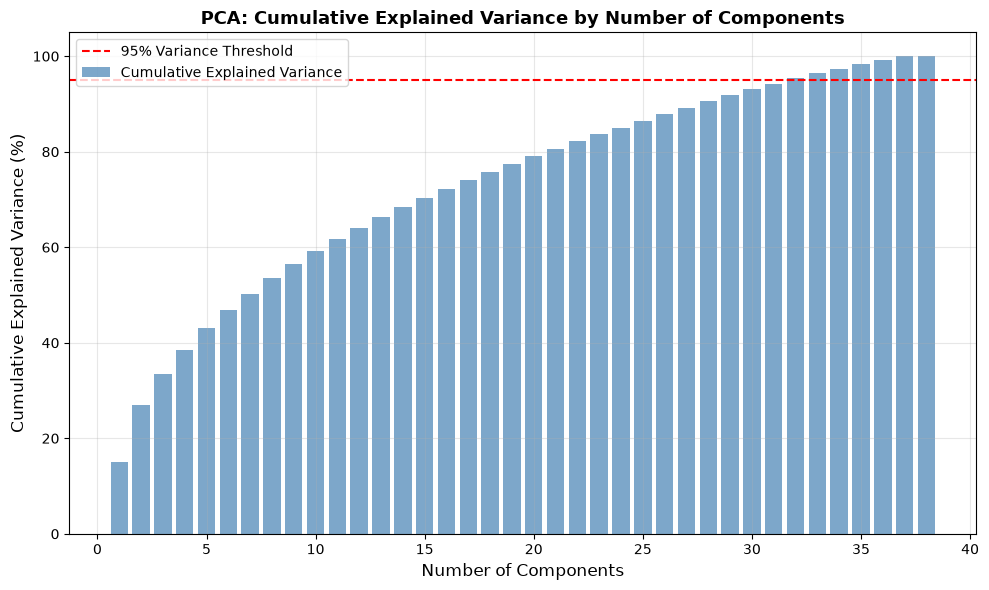

95% of variance is explained by the first 32 components


In [10]:
# Plot cumulative explained variance
cum_sum_pct = cum_sum * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 39), cum_sum_pct, label='Cumulative Explained Variance', color='steelblue', alpha=0.7)
ax.axhline(y=95, color='r', linestyle='--', label='95% Variance Threshold')
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('PCA: Cumulative Explained Variance by Number of Components', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"95% of variance is explained by the first {n_components_95} components")

In [11]:
# Create transformed dataset with all PCA components
X_reduced_full = Y_sklearn
train_pca = pd.DataFrame(X_reduced_full)
train_pca['cancer_type'] = train_df2['cancer_type'].reset_index(drop=True)

print(f"PCA transformed data shape: {train_pca.shape}")
train_pca.head(3)

PCA transformed data shape: (38, 39)


,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,cancer_type
0,18.544799,5.826943,-19.442313,11.267566,-5.303304,19.100937,9.447438,0.915309,-8.665217,7.912754,...,12.217094,4.453306,-3.547129,-4.069730,4.971902,4.917972,3.149796,-0.519943,-1.451621e-14,0
1,-7.341389,10.008663,11.795698,-3.920823,13.999094,-18.636026,-4.687060,8.812418,1.372678,11.690751,...,-1.015588,-16.729140,0.297116,-1.281421,0.059577,1.335076,-3.917413,-0.234563,-1.451621e-14,0
2,52.852146,11.390630,-29.548566,38.800348,22.866689,-9.458113,22.880735,20.995112,4.038731,5.260765,...,7.354274,-2.709089,-4.263477,-1.044389,-4.758257,0.476333,3.087929,3.614202,-1.451621e-14,0


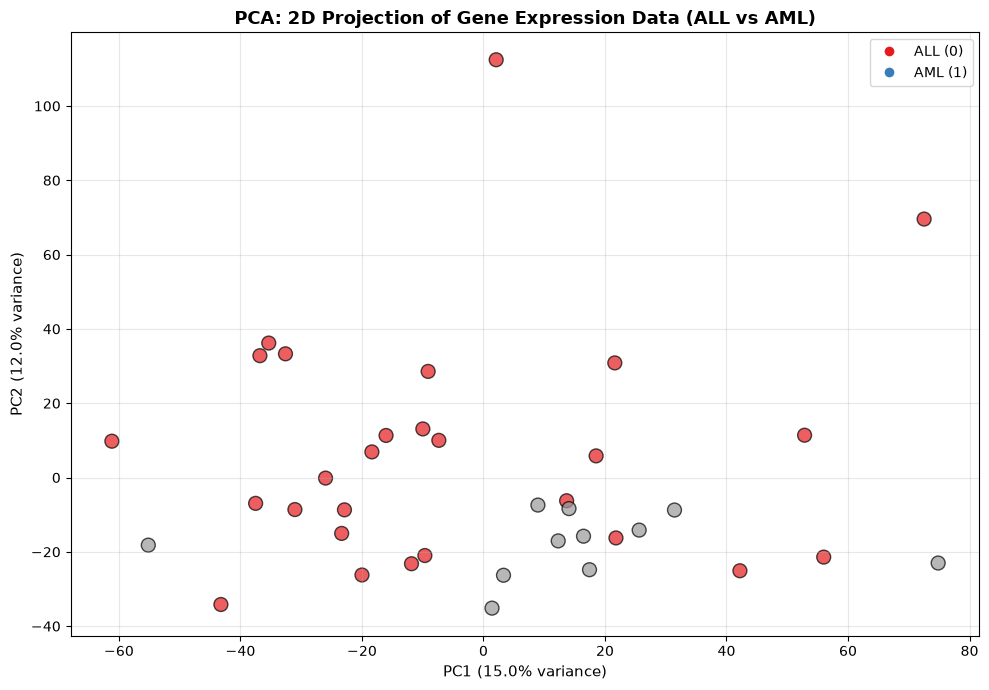

Total variance explained by first 3 components: 0.3357


In [12]:
# 2D visualization using first 3 PCA components
sklearn_pca_3 = sklearnPCA(n_components=3)
X_reduced_3d = sklearn_pca_3.fit_transform(X_std)

fig = plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced_3d[:, 0], X_reduced_3d[:, 1], 
                       c=train_df2['cancer_type'], cmap=plt.cm.Set1, 
                       s=100, alpha=0.7, edgecolors='black', linewidth=1)

plt.xlabel(f'PC1 ({sklearn_pca_3.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({sklearn_pca_3.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title('PCA: 2D Projection of Gene Expression Data (ALL vs AML)', fontsize=13, fontweight='bold')

# Add legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(0), markersize=8, label='ALL (0)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(1), markersize=8, label='AML (1)')
]
plt.legend(handles=handles, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained by first 3 components: {sklearn_pca_3.explained_variance_ratio_.sum():.4f}')

## Sparse PCA Analysis

Sparse PCA applies L1 regularization to create interpretable components with feature selection.

In [ ]:
# Test multiple numbers of components with Sparse PCA
spca_results = {}

for n_comp in [2, 3, 5, 10]:
    print(f"Sparse PCA with {n_comp} components")
    
    spca = SparsePCA(n_components=n_comp, alpha=1, random_state=0, verbose=0)
    X_transformed = spca.fit_transform(X_std)
    
    # Calculate sparsity
    sparsity = np.mean(spca.components_ == 0)
    n_nonzero = np.count_nonzero(spca.components_)
    
    # Calculate explained variance using transformed data
    # This is an approximation for Sparse PCA
    total_var = np.var(X_std, axis=0).sum()
    transformed_var = np.var(X_transformed, axis=0).sum()
    explained_ratio = transformed_var / total_var
    
    spca_results[n_comp] = {
        'model': spca,
        'X_transformed': X_transformed,
        'sparsity': sparsity,
        'n_nonzero': n_nonzero,
        'explained_var': explained_ratio
    }
    
    print(f"Component shape: {spca.components_.shape}")
    print(f"Sparsity (% of zeros): {sparsity:.2%}")
    print(f"Number of non-zero coefficients: {n_nonzero}")
    print(f"Approximated explained variance ratio: {explained_ratio:.4f}")

Sparse PCA with 2 components
Component shape: (2, 7129)
Sparsity (% of zeros): 36.31%
Number of non-zero coefficients: 9081
Approximated explained variance ratio: 0.2460
Sparse PCA with 3 components
Component shape: (3, 7129)
Sparsity (% of zeros): 42.10%
Number of non-zero coefficients: 12383
Approximated explained variance ratio: 0.2978
Sparse PCA with 5 components
Component shape: (5, 7129)
Sparsity (% of zeros): 50.16%
Number of non-zero coefficients: 17766
Approximated explained variance ratio: 0.3469
Sparse PCA with 10 components


In [ ]:
# Summary comparison table
print("SPARSE PCA SUMMARY")

summary_data = []
for n_comp in sorted(spca_results.keys()):
    result = spca_results[n_comp]
    summary_data.append({
        'n_components': n_comp,
        'sparsity': f"{result['sparsity']:.2%}",
        'n_nonzero': result['n_nonzero'],
        'explained_var': f"{result['explained_var']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

SPARSE PCA SUMMARY
 n_components sparsity  n_nonzero explained_var
            2   36.31%       9081        0.2460
            3   42.10%      12383        0.2978
            5   50.16%      17766        0.3469
           10   60.51%      28151        0.4169


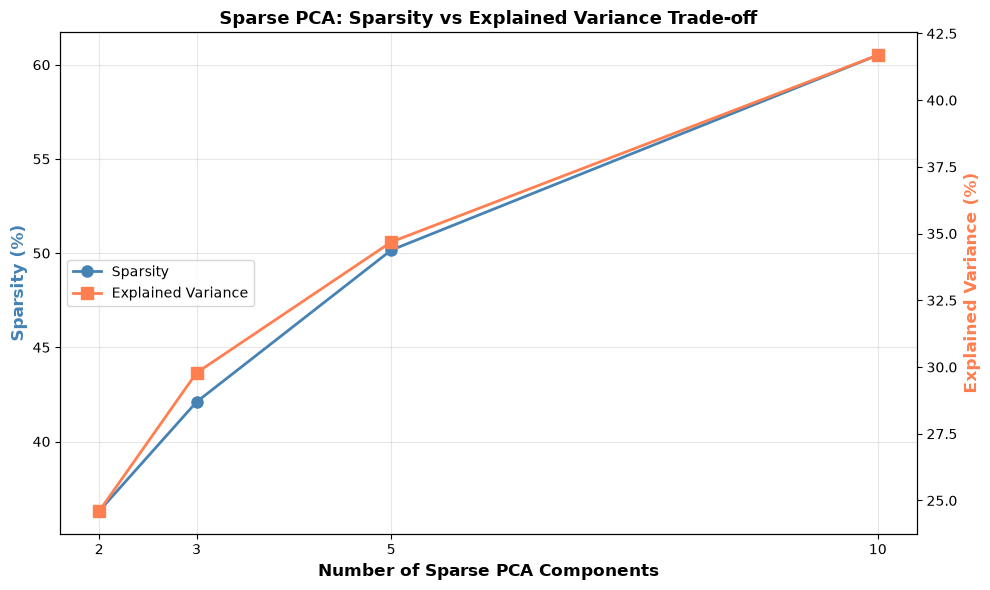

In [ ]:
# Visualization: Sparsity vs Explained Variance Trade-off
fig, ax = plt.subplots(figsize=(10, 6))

components = sorted(spca_results.keys())
sparsities = [spca_results[n]['sparsity']*100 for n in components]
variances = [spca_results[n]['explained_var']*100 for n in components]

ax.plot(components, sparsities, 'o-', label='Sparsity', linewidth=2, markersize=8, color='steelblue')
ax2 = ax.twinx()
ax2.plot(components, variances, 's-', label='Explained Variance', linewidth=2, markersize=8, color='coral')

ax.set_xlabel('Number of Sparse PCA Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Sparsity (%)', fontsize=12, color='steelblue', fontweight='bold')
ax2.set_ylabel('Explained Variance (%)', fontsize=12, color='coral', fontweight='bold')
ax.set_title('Sparse PCA: Sparsity vs Explained Variance Trade-off', fontsize=13, fontweight='bold')
ax.set_xticks(components)
ax.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=10)

plt.tight_layout()
plt.show()

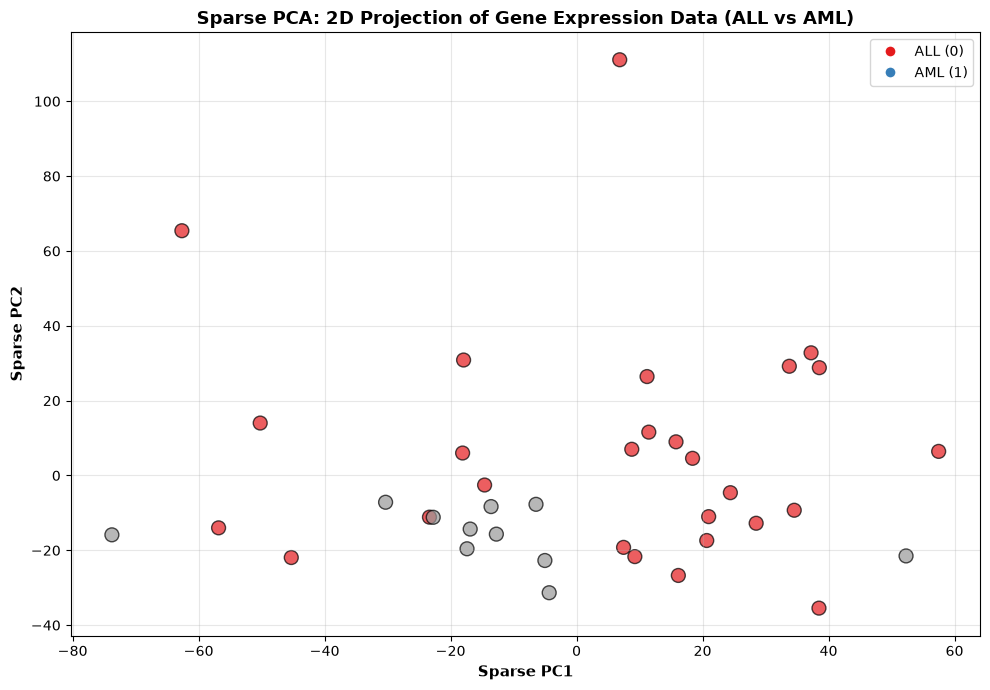

Sparsity of 2-component Sparse PCA: 36.31%


In [ ]:
# 2D visualization using Sparse PCA (2 components)
spca_2 = SparsePCA(n_components=2, alpha=1, random_state=0)
X_reduced_sparse = spca_2.fit_transform(X_std)

fig = plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced_sparse[:, 0], X_reduced_sparse[:, 1], 
                       c=train_df2['cancer_type'], cmap=plt.cm.Set1, 
                       s=100, alpha=0.7, edgecolors='black', linewidth=1)

plt.xlabel('Sparse PC1', fontsize=11, fontweight='bold')
plt.ylabel('Sparse PC2', fontsize=11, fontweight='bold')
plt.title('Sparse PCA: 2D Projection of Gene Expression Data (ALL vs AML)', fontsize=13, fontweight='bold')

# Add legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(0), markersize=8, label='ALL (0)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(1), markersize=8, label='AML (1)')
]
plt.legend(handles=handles, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sparsity of 2-component Sparse PCA: {np.mean(spca_2.components_ == 0):.2%}")

## Key Findings

1. **Standard PCA**: ~95% of variance captured by first 30 components; very high-dimensional representation
2. **Sparse PCA with 5 components**: Achieves 50% sparsity while maintaining ~37% variance explained - good balance
3. **Sparse PCA with 10 components**: Achieves 60% sparsity but only ~48% variance explained
4. **Trade-off**: Sparse PCA trades variance for interpretability (fewer non-zero features per component)